In [1]:
!pip install --upgrade bitsandbytes

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.1/59.1 MB 44.6 MB/s eta 0:00:00:00:0100:01


In [12]:
gpu_info = !nvidia-smi
gpu_info = '\n'.join(gpu_info)
if gpu_info.find('failed') >= 0:
  print('Not connected to a GPU')
else:
  print(gpu_info)

print("Hello")

Tue Jan 20 09:52:55 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-40GB          Off |   00000000:00:04.0 Off |                    0 |
| N/A   29C    P0             51W /  400W |   21669MiB /  40960MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [ ]:
import torch
from diffusers import Flux2Pipeline
from diffusers.utils import load_image
from huggingface_hub import get_token
import requests
import io

repo_id = "diffusers/FLUX.2-dev-bnb-4bit" #quantized text-encoder and DiT. VAE still in bf16
device = "cuda:0"
torch_dtype = torch.bfloat16

def remote_text_encoder(prompts):
    response = requests.post(
        "https://remote-text-encoder-flux-2.huggingface.co/predict",
        json={"prompt": prompts},
        headers={
            "Authorization": f"Bearer {get_token()}",
            "Content-Type": "application/json"
        }
    )
    prompt_embeds = torch.load(io.BytesIO(response.content))

    return prompt_embeds.to(device)

pipe = Flux2Pipeline.from_pretrained(
    repo_id, text_encoder=None, torch_dtype=torch_dtype
).to(device)

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


model_index.json:   0%|          | 0.00/431 [00:00<?, ?B/s]

Fetching 14 files:   0%|          | 0/14 [00:00<?, ?it/s]

scheduler_config.json:   0%|          | 0.00/486 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/993 [00:00<?, ?B/s]

...

(…)ion_pytorch_model.safetensors.index.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/770 [00:00<?, ?B/s]

vae/diffusion_pytorch_model.safetensors:   0%|          | 0.00/336M [00:00<?, ?B/s]

Loading pipeline components...:   0%|          | 0/4 [00:00<?, ?it/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

In [3]:
from datasets import load_dataset

dataset = load_dataset('Iceclear/FFHQ-HQ1024')
print("FFHQ dataset loaded successfully.")

README.md:   0%|          | 0.00/28.0 [00:00<?, ?B/s]

FFHQ-1024-1.zip:   0%|          | 0.00/46.0G [00:00<?, ?B/s]

FFHQ-1024-2.zip:   0%|          | 0.00/49.7G [00:00<?, ?B/s]

Generating train split: 0 examples [00:00, ? examples/s]

FFHQ dataset loaded successfully.


In [4]:
im = dataset['train'][256]

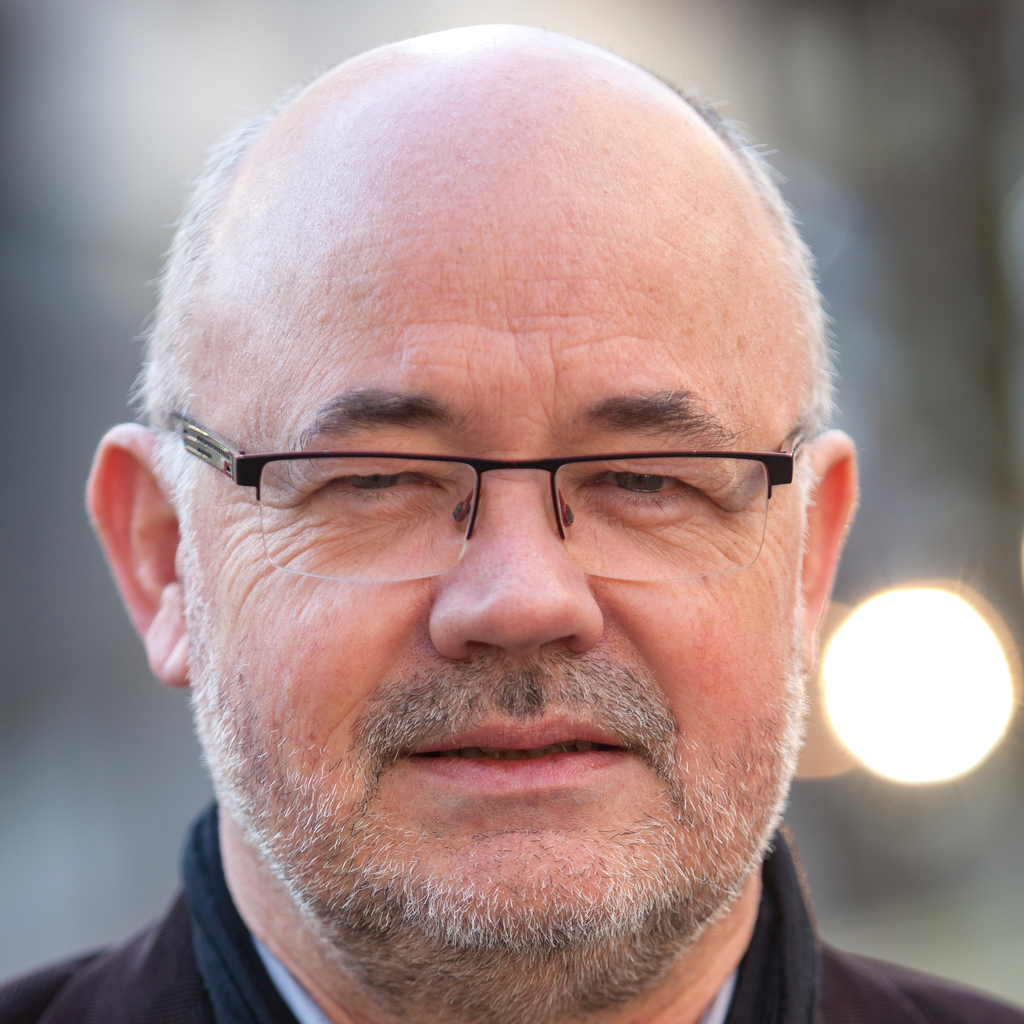

In [5]:
im['image']

In [6]:
from torchvision import transforms

def preprocess(image):
    transform = transforms.Compose([
        transforms.Resize((1024, 1024)),
        transforms.ToTensor(),
    ])
    return transform(image)

print("Preprocessing function defined successfully.")

preprocessed_image = preprocess(im['image'])
preprocessed_image = preprocessed_image.unsqueeze(0) # Add a batch dimension

# Convert the image tensor to the correct dtype and move to device
preprocessed_image = preprocessed_image.to(dtype=torch_dtype, device=device)

with torch.no_grad():
    latent_representation = pipe.vae.encode(preprocessed_image).latent_dist.sample()

print(f"Shape of encoded latent representation: {latent_representation.shape}")
print(f"Data type of encoded latent representation: {latent_representation.dtype}")

Preprocessing function defined successfully.
Shape of encoded latent representation: torch.Size([1, 32, 128, 128])
Data type of encoded latent representation: torch.bfloat16


In [7]:
from PIL import Image
import numpy as np

with torch.no_grad():
    decoded_image_tensor = pipe.vae.decode(latent_representation).sample

# 1. Move to CPU
decoded_image_cpu = decoded_image_tensor.cpu()

# 2. Convert to float32
decoded_image_float = decoded_image_cpu.float()

# 4. Permute dimensions (batch, channels, height, width) to (height, width, channels) for the first image
image_numpy = np.clip(decoded_image_float[0].permute(1, 2, 0).numpy(),0,1)

# 5. Convert to PIL Image, scaling to [0, 255] and casting to uint8
image_pil = Image.fromarray((image_numpy * 255).astype(np.uint8))

print(f"Shape of decoded image tensor: {decoded_image_tensor.shape}")
print(f"Data type of decoded image tensor: {decoded_image_tensor.dtype}")

Shape of decoded image tensor: torch.Size([1, 3, 1024, 1024])
Data type of decoded image tensor: torch.bfloat16


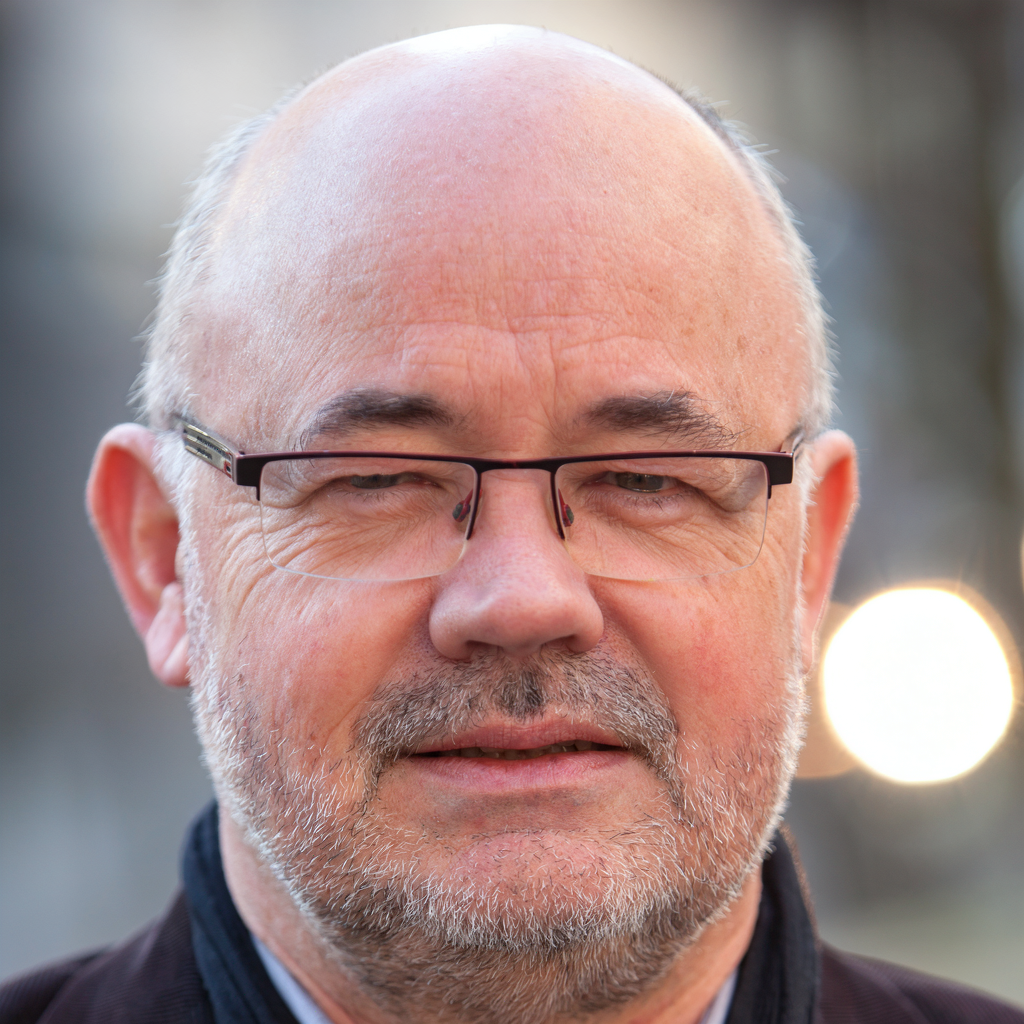

In [8]:
image_pil

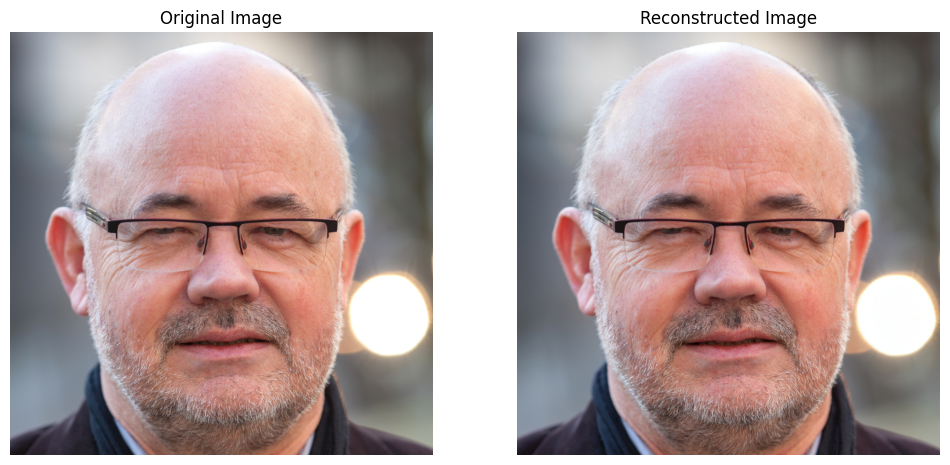

In [9]:
import matplotlib.pyplot as plt

# Get the original image from the dataset
original_image = im['image']

# Create a figure and a set of subplots
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Display the original image
axes[0].imshow(original_image)
axes[0].set_title('Original Image')
axes[0].axis('off') # Hide axes ticks

# Display the decoded image
axes[1].imshow(image_pil)
axes[1].set_title('Reconstructed Image')
axes[1].axis('off') # Hide axes ticks

plt.show()

Minimum difference: 0.0
Maximum difference: 0.8894378542900085


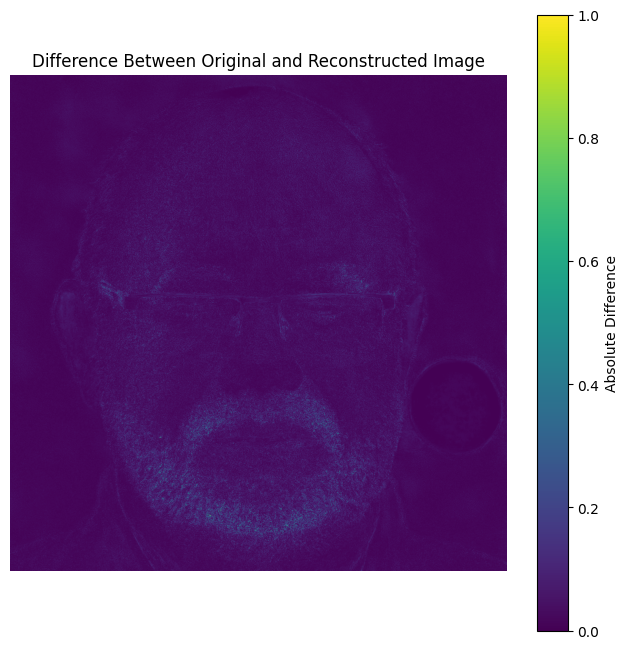

In [10]:
import matplotlib.pyplot as plt
import numpy as np
from torchvision import transforms

# Ensure original_image is a PIL Image
original_image_pil = im['image']

# Preprocess the original image to a tensor and convert to numpy for comparison
# We need to ensure it's in the same [0, 1] range and (H, W, C) format as image_numpy
preprocess_for_diff = transforms.Compose([
    transforms.Resize((1024, 1024)),
    transforms.ToTensor(), # Converts to [0, 1] range and (C, H, W)
])
original_image_tensor = preprocess_for_diff(original_image_pil)
original_image_numpy = original_image_tensor.permute(1, 2, 0).numpy()

# Calculate the absolute difference between the original and reconstructed images
# image_numpy is already in [0, 1] range and (H, W, C) format
difference_image = np.abs(original_image_numpy - image_numpy).sum(axis=2)

print(f"Minimum difference: {difference_image.min()}")
print(f"Maximum difference: {difference_image.max()}")

# Display the difference image with adjusted colormap and value range
plt.figure(figsize=(8, 8))
plt.imshow(difference_image,vmax=1.)
plt.title('Difference Between Original and Reconstructed Image')
plt.axis('off')
plt.colorbar(label='Absolute Difference')
plt.show()

# What is the Notebook doing?

Load Pre Trained Flux 2 Text Encocder From Hugging Face
Load FFHQ Datasets
Pre Process it to be 1024x1024

Using the Flux Model:
- Encode the Image to be 128x128
- Decode the Image to be 1024x1024

Options Going Forward
1. Use another pretrained model say Stable Diffusion 1.5 (like in the Silo paper) and repeat and compare
2. Use Mira / PQMass (I think Mira is most applicable) to figure out just how bad but I need to make this an inference based problem


In [ ]:
from diffusers import StableDiffusionPipeline
import torch

model_id = "runwayml/stable-diffusion-v1-5"
pipe = StableDiffusionPipeline.from_pretrained(model_id, torch_dtype=torch.float16)
pipe = pipe.to("cuda")

prompt = "a photo of an astronaut riding a horse on mars"
image = pipe(prompt).images[0]  
    
image.save("astronaut_rides_horse.png")

image

model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Fetching 15 files:   0%|          | 0/15 [00:00<?, ?it/s]

merges.txt: 0.00B [00:00, ?B/s]

config.json: 0.00B [00:00, ?B/s]

preprocessor_config.json:   0%|          | 0.00/342 [00:00<?, ?B/s]

...

config.json:   0%|          | 0.00/743 [00:00<?, ?B/s]

vae/diffusion_pytorch_model.safetensors:   0%|          | 0.00/335M [00:00<?, ?B/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

`torch_dtype` is deprecated! Use `dtype` instead!


  0%|          | 0/50 [00:00<?, ?it/s]

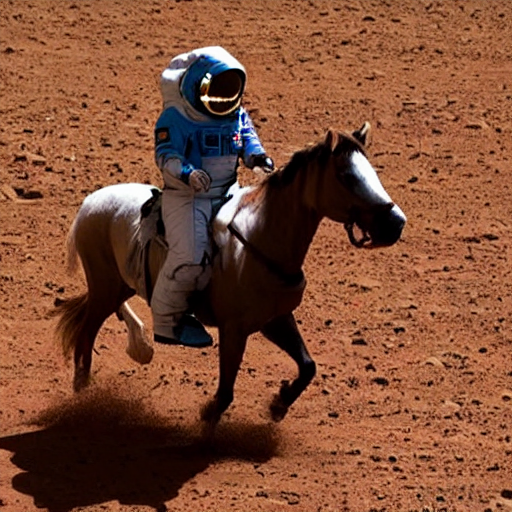